# Prática: Optimizers, Schedulers and Loss

In [1]:
# %pip install -q plotly matplotlib numpy torch torchvision

# Importações

In [2]:
# Importações + Reprodutibilidade

import random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from IPython.display import display, HTML

# ============================================================
# Reprodutibilidade
# ============================================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Mantém resultados tão determinísticos quanto possível
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Seed: {SEED}')
print(f'Dispositivo: {device}')


Seed: 42
Dispositivo: cpu


# Baixando o Dataset

Usamos o **FashionMNIST**: imagens de roupas (28×28, escala de cinza) com 10 classes.

In [3]:
# ============================================================
# Carregamento e Pré-processamento dos dados
# ============================================================
# FashionMNIST fornece imagens 28x28 em escala de cinza.
#
# Convertemos as imagens para tensor, o que automaticamente
# escala os valores dos pixels para o intervalo [0.0, 1.0],
# preservando todos os tons de cinza originais.

transform = transforms.Compose([transforms.ToTensor()])
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)q
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Geradores separados tornam o embaralhamento reproduzível.
generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    generator=generator
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print(f'Amostras de treino: {len(train_dataset):,}')
print(f'Amostras de teste:  {len(test_dataset):,}')
print(f'Classes: {train_dataset.classes}')

# Inspeção de um batch
images, labels = next(iter(train_loader))
print(f'Forma de um batch: {images.shape}')
print(f'Tipo dos pixels: {images.dtype}')
print(f'Valores mínimo e máximo nos pixels: {images.min().item()} a {images.max().item()}')


100%|██████████| 26.4M/26.4M [00:01<00:00, 19.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 309kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.64MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.2MB/s]


Amostras de treino: 60,000
Amostras de teste:  10,000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Forma de um batch: torch.Size([64, 1, 28, 28])
Tipo dos pixels: torch.float32
Valores mínimo e máximo nos pixels: 0.0 a 1.0


# Exemplos por classe

Uma imagem real de cada uma das **10 classes** do FashionMNIST, em um grid **5×2**.


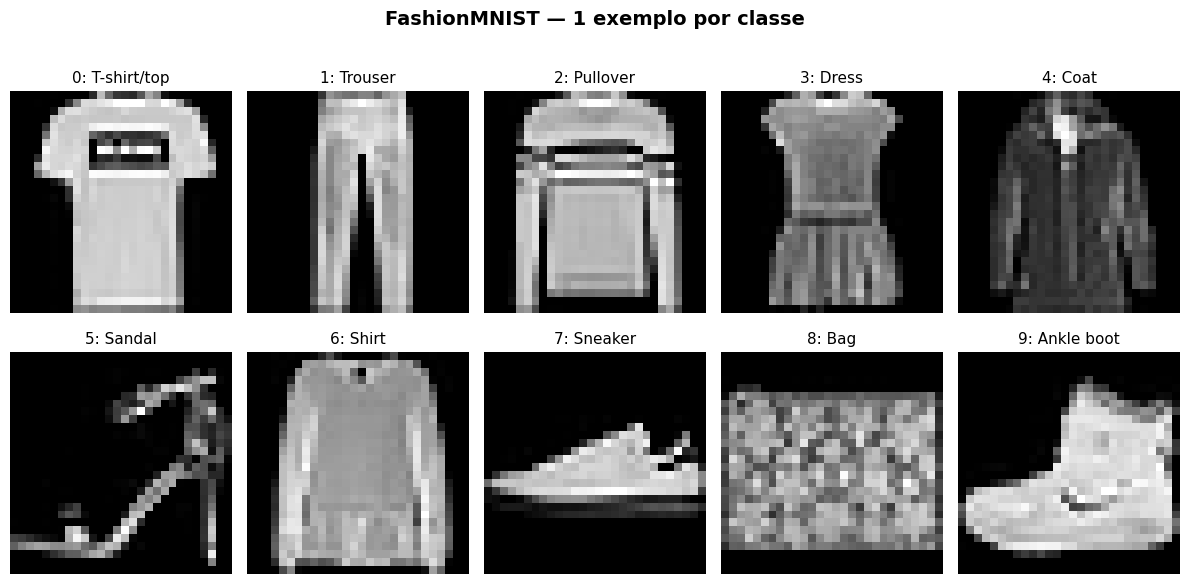

In [4]:
# Uma amostra real de cada classe do FashionMNIST (grid 2x5)
classes_fm = train_dataset.classes

# índice da primeira imagem de cada classe (0..9)
idx_por_classe = {}
for i in range(len(train_dataset)):
    y = train_dataset[i][1]
    if y not in idx_por_classe:
        idx_por_classe[y] = i
    if len(idx_por_classe) == 10:
        break

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()
for classe, ax in enumerate(axes):
    img, _ = train_dataset[idx_por_classe[classe]]
    ax.imshow(img.squeeze().numpy(), cmap='gray')
    ax.set_title(f'{classe}: {classes_fm[classe]}', fontsize=11)
    ax.axis('off')

fig.suptitle('FashionMNIST — 1 exemplo por classe', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
# Exploração dos Dados

Antes de treinar, vamos verificar a estrutura dos dados que realmente
chegará à rede.

Cada imagem possui **1 canal × 28 × 28 pixels**. O `DataLoader` reúne
essas imagens em mini-batches. Como fizemos a binarização, os pixels
assumem apenas os valores 0 e 1.

Também verificamos a distribuição das classes no conjunto de treinamento.


Formato de uma imagem: torch.Size([1, 28, 28])
Rótulo da primeira imagem: 9
Nome da classe: Ankle boot


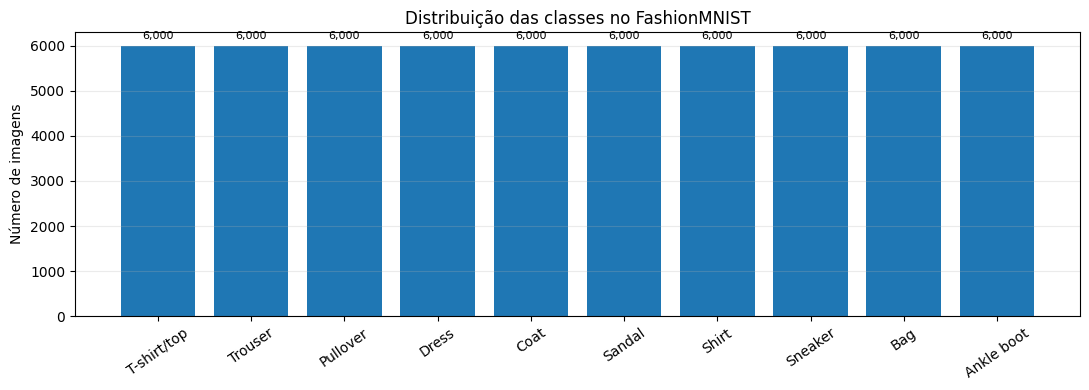

In [5]:
# Forma, valores e distribuição das classes

print('Formato de uma imagem:', train_dataset[0][0].shape)
print('Rótulo da primeira imagem:', train_dataset[0][1])
print('Nome da classe:', classes_fm[train_dataset[0][1]])

contagens = np.bincount(
    [train_dataset[i][1] for i in range(len(train_dataset))],
    minlength=10
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(classes_fm, contagens)
ax.set_title('Distribuição das classes no FashionMNIST')
ax.set_ylabel('Número de imagens')
ax.tick_params(axis='x', rotation=35)
ax.grid(axis='y', alpha=0.25)

for i, v in enumerate(contagens):
    ax.text(i, v + 150, f'{v:,}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()


# Criando a Rede Neural Convolucional (CNN)

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # 1. Extrai características locais (mantém 28x28 devido ao padding=1)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)

        # 2. Ativação
        self.relu = nn.ReLU()

        # 3. Reduz a dimensão pela metade (de 28x28 para 14x14)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # 4. Camada final de decisão (16 canais * 14px * 14px = 3136 entradas -> 10 saídas)
        self.fc1 = nn.Linear(16 * 14 * 14, 10)

    def forward(self, x):
        # Passo 1: Extrai características visuais (bordas, curvas)
        # Mantém dimensão: [64, 16, 28, 28]
        x = self.conv1(x)

        # Passo 2: Aplica ativação (zera o que é irrelevante)
        # Mantém dimensão: [64, 16, 28, 28]
        x = self.relu(x)

        # Passo 3: Comprime a imagem pela metade (resumo visual)
        # Reduz dimensão: [64, 16, 14, 14]
        x = self.pool(x)

        # Passo 4: Achata a imagem 3D em um vetor 1D (Flatten)
        # Transforma 16 canais de 14x14 em 3136 números por imagem
        x = x.view(-1, 16 * 14 * 14)  # Resultado: [64, 3136]

        # Passo 5: Camada final toma a decisão de classificação
        # Transforma 3136 entradas em 10 probabilidades de saída
        x = self.fc1(x)  # Resultado: [64, 10]
        return x

model = SimpleCNN()
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=10, bias=True)
)


---
# Remodelagem dos Dados

As imagens entram na CNN com quatro dimensões:

`[batch, canais, altura, largura]`

No FashionMNIST:

`[64, 1, 28, 28]`

Depois das convoluções e do *pooling*, a rede precisa transformar
os mapas de características em vetores para a camada `Linear`.
Esse passo é o **Flatten** mostrado no `forward()` da CNN.


In [7]:
# Demonstração do formato antes e depois do Flatten

with torch.no_grad():
    x_demo = images[:4]
    x_conv = model.pool(model.relu(model.conv1(x_demo)))
    x_flat = x_conv.view(x_conv.size(0), -1)

print('Entrada da CNN :', x_demo.shape)
print('Após Conv+ReLU+Pool:', x_conv.shape)
print('Após Flatten    :', x_flat.shape)
print('Saída final     :', model(x_demo).shape)


Entrada da CNN : torch.Size([4, 1, 28, 28])
Após Conv+ReLU+Pool: torch.Size([4, 16, 14, 14])
Após Flatten    : torch.Size([4, 3136])
Saída final     : torch.Size([4, 10])


---

# 1. Função de Perda (*Loss*)

A **loss** (função de perda) responde: *"o quão errado o modelo está?"*

Durante o treino, o modelo faz uma previsão. A loss compara essa previsão com o rótulo verdadeiro e devolve um **número**: quanto **maior**, pior; quanto **menor**, melhor. O objetivo do treino é **minimizar** a loss.

### Analogia
Imagine um aluno fazendo uma prova. A loss é a **nota de erro**: 0 = acertou tudo; valores altos = muitos erros. O professor (otimizador) usa essa nota para corrigir o estudo do aluno.

### Funções comuns no PyTorch

| Função | Quando usar |
|---|---|
| `nn.CrossEntropyLoss()` | Classificação com **várias** classes (ex.: 10 tipos de roupa) |
| `nn.BCELoss()` / `nn.BCEWithLogitsLoss()` | Classificação **binária** (duas classes) |
| `nn.MSELoss()` | **Regressão** (prever um número contínuo) |

No FashionMNIST usamos **CrossEntropyLoss**, porque temos 10 classes.

A célula de código abaixo:
1. Pega **3 imagens reais** do FashionMNIST (T-shirt, Trouser, Pullover);
2. Passa pelo modelo e marca cada amostra na curva `-log(p)`;
3. Mostra a loss de cada peça e cria o `criterion` do treino.


In [8]:
# --- Visualização didática da Loss (com amostras reais do FashionMNIST) ---

classes_fm = train_dataset.classes
criterion_demo = nn.CrossEntropyLoss(reduction='none')
criterion = nn.CrossEntropyLoss()

# Uma imagem real por classe: T-shirt / Trouser / Pullover
idx_demo = []
for classe_alvo in (0, 1, 2):
    for i in range(len(train_dataset)):
        if train_dataset[i][1] == classe_alvo:
            idx_demo.append(i)
            break

imagens_demo = torch.stack([train_dataset[i][0] for i in idx_demo])
rotulos_demo = torch.tensor([train_dataset[i][1] for i in idx_demo])

model.eval()
with torch.no_grad():
    logits_reais = model(imagens_demo)
    probs_reais = torch.softmax(logits_reais, dim=1)
    perdas_reais = criterion_demo(logits_reais, rotulos_demo).numpy()
    # p = probabilidade que o modelo atribui à classe CORRETA de cada imagem
    p_classe_correta = probs_reais[range(len(rotulos_demo)), rotulos_demo].numpy()


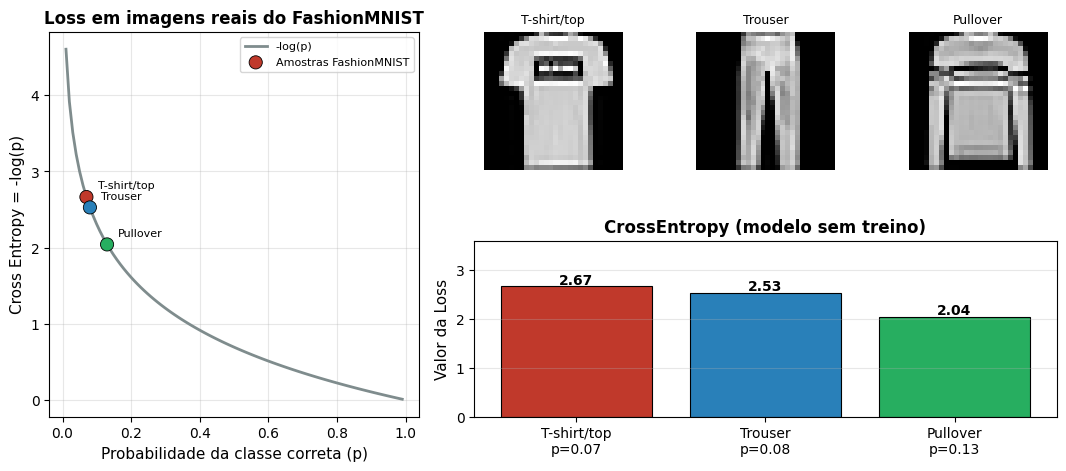

criterion = nn.CrossEntropyLoss()  → mede o erro de classificação em 10 classes do FashionMNIST
  T-shirt/top   p(classe correta)=0.070  loss=2.665
  Trouser       p(classe correta)=0.080  loss=2.528
  Pullover      p(classe correta)=0.130  loss=2.042


In [9]:
# Curva teórica -log(p) + pontos reais do FashionMNIST
probs_curva = np.linspace(0.01, 0.99, 100)
cross_entropy = -np.log(probs_curva)

fig = plt.figure(figsize=(13, 5))
gs = fig.add_gridspec(2, 5, height_ratios=[1.1, 1.4], hspace=0.45, wspace=0.35)

ax_curva = fig.add_subplot(gs[:, 0:2])
ax_curva.plot(probs_curva, cross_entropy, color='#7f8c8d', linewidth=2, label='-log(p)')
cores = ['#c0392b', '#2980b9', '#27ae60']
ax_curva.scatter(
    p_classe_correta, -np.log(np.clip(p_classe_correta, 1e-8, 1)),
    c=cores, s=90, zorder=5, edgecolors='black', linewidths=0.6,
    label='Amostras FashionMNIST',
)
for p, nome in zip(p_classe_correta, [classes_fm[r] for r in rotulos_demo]):
    ax_curva.annotate(
        nome, (p, -np.log(max(p, 1e-8))),
        textcoords='offset points', xytext=(8, 6), fontsize=8,
    )
ax_curva.set_xlabel('Probabilidade da classe correta (p)', fontsize=11)
ax_curva.set_ylabel('Cross Entropy = -log(p)', fontsize=11)
ax_curva.set_title('Loss em imagens reais do FashionMNIST', fontsize=12, fontweight='bold')
ax_curva.legend(fontsize=8, loc='upper right')
ax_curva.grid(True, alpha=0.3)

# Miniaturas das 3 peças
for i in range(3):
    ax_img = fig.add_subplot(gs[0, 2 + i])
    ax_img.imshow(imagens_demo[i].squeeze().numpy(), cmap='gray')
    ax_img.set_title(classes_fm[rotulos_demo[i]], fontsize=9)
    ax_img.axis('off')

# Barras de loss das mesmas imagens
ax_bar = fig.add_subplot(gs[1, 2:])
nomes = [f'{classes_fm[r]}\np={p:.2f}' for r, p in zip(rotulos_demo, p_classe_correta)]
barras = ax_bar.bar(nomes, perdas_reais, color=cores, edgecolor='black', linewidth=0.8)
ax_bar.set_ylabel('Valor da Loss', fontsize=11)
ax_bar.set_title('CrossEntropy (modelo sem treino)', fontsize=12, fontweight='bold')
for barra, valor in zip(barras, perdas_reais):
    ax_bar.text(
        barra.get_x() + barra.get_width() / 2, valor + 0.05,
        f'{valor:.2f}', ha='center', fontsize=10, fontweight='bold',
    )
ax_bar.set_ylim(0, max(float(perdas_reais.max()) * 1.35, 0.5))
ax_bar.grid(True, axis='y', alpha=0.3)

plt.show()

print('criterion = nn.CrossEntropyLoss()  → mede o erro de classificação em 10 classes do FashionMNIST')
for nome, p, loss in zip([classes_fm[r] for r in rotulos_demo], p_classe_correta, perdas_reais):
    print(f'  {nome:12s}  p(classe correta)={p:.3f}  loss={loss:.3f}')

---

# 2. Otimizador (*Optimizer*) e Descida do Gradiente

A loss diz **quanto** erramos. O **otimizador** decide **como** corrigir os pesos da rede.

### Ideia central: Descida do Gradiente
1. Calculamos o **gradiente** da loss em relação a cada peso (`loss.backward()`).
2. O gradiente aponta a direção de **maior subida** da loss.
3. O otimizador dá um passo na direção **oposta** (descida):  
   `peso_novo = peso_antigo - taxa_de_aprendizado × gradiente`

A **taxa de aprendizado (lr)** é o tamanho do passo:
- `lr` muito grande → pode "pular" o mínimo e divergir;
- `lr` muito pequeno → aprende devagar demais.

### Otimizadores populares
| Otimizador | Ideia |
|---|---|
| **SGD** | Passo simples na direção do gradiente |
| **SGD + Momentum** | Acumula velocidade (como uma bola rolando) |
| **Adam** | Adapta o passo por parâmetro (muito usado na prática) |

No nosso treino usamos **Adam** com `lr=0.01`.

A visualização 3D abaixo **não usa uma superfície inventada**: ela calcula a loss logística em um subconjunto real do FashionMNIST (T-shirt vs Trouser), com 2 features simples das imagens (brilho médio da metade superior e da inferior). Assim você vê a descida do gradiente sobre dados reais.


In [17]:
# --- Superfície 3D da Loss no FashionMNIST (T-shirt vs Trouser) + Descida do Gradiente ---

# Subconjunto binário real: classe 0 (T-shirt) vs classe 1 (Trouser)
n_por_classe = 80
xs, ys = [], []
contagem = {0: 0, 1: 0}
for img, y_lab in train_dataset:
    if y_lab in contagem and contagem[y_lab] < n_por_classe:
        arr = img.squeeze().numpy()  # 28x28
        # 2 features interpretáveis: brilho médio do topo e da base da peça
        f1 = float(arr[:14, :].mean())
        f2 = float(arr[14:, :].mean())
        xs.append([f1, f2])
        ys.append(float(y_lab))
        contagem[y_lab] += 1
    if contagem[0] >= n_por_classe and contagem[1] >= n_por_classe:
        break

X = np.asarray(xs, dtype=np.float64)
y = np.asarray(ys, dtype=np.float64)
# padroniza features (ajuda a visualizar o vale)
X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)


def loss_surface(w1, w2, X=X, y=y):
    """BCE com logits sobre dados reais do FashionMNIST."""
    w1 = np.asarray(w1, dtype=np.float64)
    w2 = np.asarray(w2, dtype=np.float64)
    logits = w1[..., None] * X[:, 0] + w2[..., None] * X[:, 1]
    # softplus(logits) - y*logits  == BCEWithLogits, estável numericamente
    softplus = np.log1p(np.exp(-np.abs(logits))) + np.maximum(logits, 0)
    return np.mean(softplus - y * logits, axis=-1)


def gradiente(w1, w2, X=X, y=y):
    logits = w1 * X[:, 0] + w2 * X[:, 1]
    probs = 1.0 / (1.0 + np.exp(-logits))
    err = probs - y
    dw1 = np.mean(err * X[:, 0])
    dw2 = np.mean(err * X[:, 1])
    return dw1, dw2


def descer_gradiente(w1_ini, w2_ini, lr=0.35, passos=50):
    traj_w1, traj_w2, traj_L = [w1_ini], [w2_ini], [float(loss_surface(w1_ini, w2_ini))]
    w1, w2 = w1_ini, w2_ini
    for _ in range(passos):
        dw1, dw2 = gradiente(w1, w2)
        w1 = w1 - lr * dw1
        w2 = w2 - lr * dw2
        traj_w1.append(w1)
        traj_w2.append(w2)
        traj_L.append(float(loss_surface(w1, w2)))
    return traj_w1, traj_w2, traj_L


# Grade para a superfície
w1_grid = np.linspace(-4.0, 4.0, 70)
w2_grid = np.linspace(-4.0, 4.0, 70)
W1, W2 = np.meshgrid(w1_grid, w2_grid)
L = loss_surface(W1, W2)

# Trajetória a partir de um ponto ruim
traj_w1, traj_w2, traj_L = descer_gradiente(w1_ini=-3.0, w2_ini=3.0, lr=0.4, passos=55)
w1_star, w2_star = traj_w1[-1], traj_w2[-1]

fig = go.Figure()

fig.add_trace(go.Surface(
    x=W1, y=W2, z=L,
    colorscale='Viridis',
    opacity=0.85,
    name='Loss no FashionMNIST',
    colorbar=dict(title='BCE (T-shirt vs Trouser)'),
    hovertemplate='w₁=%{x:.2f}<br>w₂=%{y:.2f}<br>Loss=%{z:.3f}<extra></extra>',
))

fig.add_trace(go.Scatter3d(
    x=traj_w1, y=traj_w2, z=traj_L,
    mode='lines+markers',
    line=dict(color='red', width=6),
    marker=dict(size=3, color=list(range(len(traj_L))), colorscale='Reds', showscale=False),
    name='Descida do Gradiente',
    hovertemplate='passo=%{marker.color}<br>Loss=%{z:.3f}<extra></extra>',
))

fig.add_trace(go.Scatter3d(
    x=[traj_w1[0]], y=[traj_w2[0]], z=[traj_L[0]],
    mode='markers+text',
    marker=dict(size=8, color='orange', symbol='diamond'),
    text=['Início'], textposition='top center',
    name='Ponto inicial',
))
fig.add_trace(go.Scatter3d(
    x=[w1_star], y=[w2_star], z=[traj_L[-1]],
    mode='markers+text',
    marker=dict(size=8, color='lime', symbol='diamond'),
    text=['Mínimo approx.'], textposition='bottom center',
    name='Após descida',
))

fig.update_layout(
    title=dict(
        text='Descida do Gradiente em 3D sobre loss real (FashionMNIST: T-shirt vs Trouser)',
        font=dict(size=15),
    ),
    scene=dict(
        xaxis_title='peso w₁ (brilho topo)',
        yaxis_title='peso w₂ (brilho base)',
        zaxis_title='Loss BCE',
        camera=dict(eye=dict(x=1.6, y=1.6, z=1.1)),
    ),
    legend=dict(x=0.02, y=0.98),
    width=900,
    height=650,
    margin=dict(l=0, r=0, t=60, b=0),
)

# O renderer explícito evita que o Colab tente abrir a figura em
# um backend incompatível. O fallback transforma a figura em HTML
# embutido na própria célula.
try:
    fig.show(renderer='colab')
except Exception as e:
    print('Renderer Colab indisponível; usando HTML embutido.')
    display(HTML(fig.to_html(include_plotlyjs='cdn')))

print(f'Amostras usadas: {len(y)} imagens FashionMNIST (T-shirt vs Trouser)')
print(f'Loss inicial: {traj_L[0]:.3f}  →  Loss final: {traj_L[-1]:.3f}')
print('Gire o gráfico com o mouse para ver o caminho descendo o vale.')

# Optimizer real do nosso modelo CNN
optimizer = optim.Adam(model.parameters(), lr=0.01)
print('optimizer = optim.Adam(model.parameters(), lr=0.01)')


# ============================================================
# Experimento conceitual: diferentes Optimizers
# ============================================================
# Aqui comparamos o comportamento dos otimizadores em um problema
# simples. Não substitui o optimizer real da CNN; serve para entender
# o papel do algoritmo de atualização.

print('\nComparação conceitual de Optimizers:')
print('  SGD  -> atualização baseada diretamente no gradiente')
print('  SGD + Momentum -> acumula velocidade')
print('  Adam -> adapta o passo para cada parâmetro')
print('No treinamento da CNN usaremos Adam.')


Amostras usadas: 160 imagens FashionMNIST (T-shirt vs Trouser)
Loss inicial: 1.209  →  Loss final: 0.630
Gire o gráfico com o mouse para ver o caminho descendo o vale.
optimizer = optim.Adam(model.parameters(), lr=0.01)

Comparação conceitual de Optimizers:
  SGD  -> atualização baseada diretamente no gradiente
  SGD + Momentum -> acumula velocidade
  Adam -> adapta o passo para cada parâmetro
No treinamento da CNN usaremos Adam.


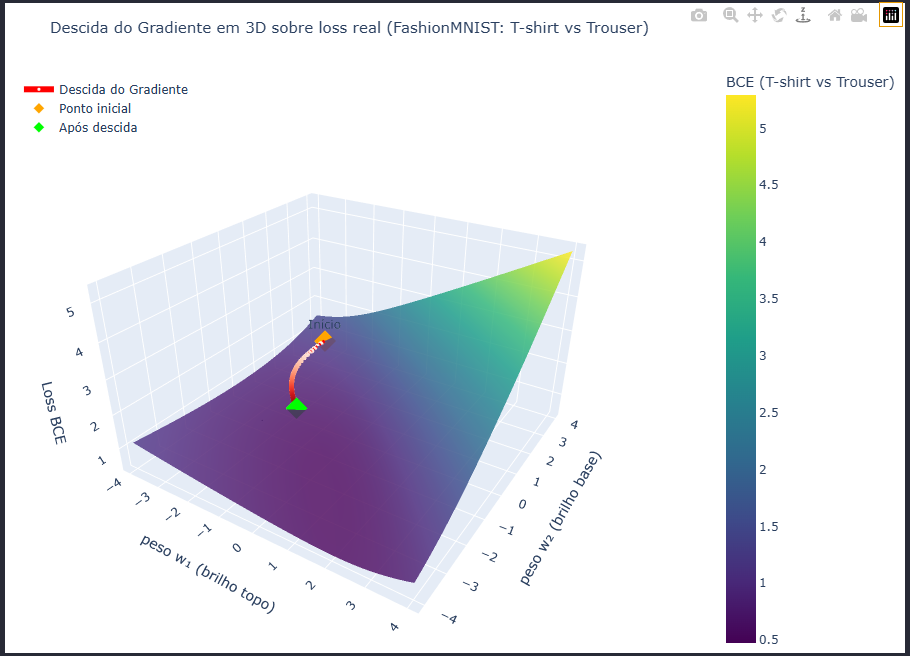

---

# 3. Scheduler (Agendador da Taxa de Aprendizado)

O **scheduler** muda a taxa de aprendizado (**lr**) ao longo do treino.

### Por que isso importa?
- No **início**, um `lr` maior ajuda a explorar e cair rápido no vale da loss.
- Perto do **fim**, um `lr` menor permite ajustes finos — como uma câmera que começa com zoom amplo e depois foca no detalhe.

Sem o scheduler, o passo fica sempre do mesmo tamanho e o modelo pode oscilar em torno do mínimo.

### Exemplos no PyTorch
| Scheduler | Comportamento |
|---|---|
| `StepLR` | A cada N épocas, multiplica o lr por `gamma` (ex.: divide pela metade) |
| `ExponentialLR` | Decai exponencial contínua |
| `CosineAnnealingLR` | Segue uma curva senoidal suave até um mínimo |
| `ReduceLROnPlateau` | Reduz o lr só quando a loss para de melhorar |

No nosso treino usamos:
```python
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
```
Ou seja: a cada **2 épocas**, a taxa fica **50%** do valor anterior (`0.01 → 0.005 → 0.0025…`).

A célula abaixo compara visualmente três schedulers e configura o `StepLR` do treino.

# Modelo e componentes finais serão executados no dispositivo escolhido.
model = model.to(device)
print(f'Modelo movido para: {device}')


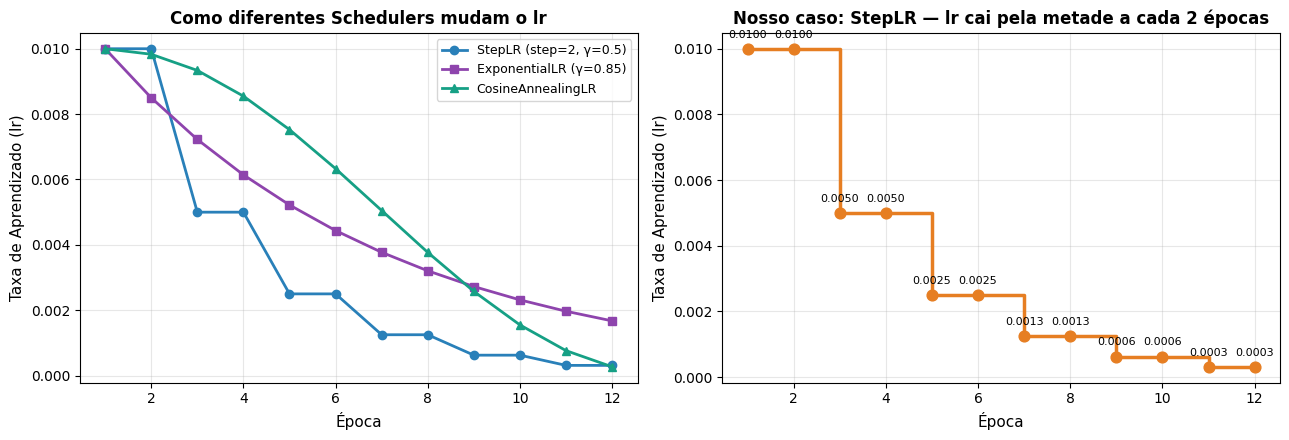

scheduler = StepLR(optimizer, step_size=2, gamma=0.5)
lr inicial: 0.01


In [11]:
# --- Comparação visual de Schedulers ---

epocas_demo = 12
lr_inicial = 0.01


def simular_scheduler(factory, epocas=epocas_demo):
    """Cria um modelo/otimizador dummy só para registrar o lr a cada época."""
    dummy = nn.Linear(1, 1)
    opt = optim.SGD(dummy.parameters(), lr=lr_inicial)
    sch = factory(opt)
    historico = []
    for _ in range(epocas):
        historico.append(opt.param_groups[0]['lr'])
        # passo fictício para o scheduler avançar
        opt.step()
        sch.step()
    return historico


lrs_step = simular_scheduler(
    lambda opt: optim.lr_scheduler.StepLR(opt, step_size=2, gamma=0.5)
)
lrs_exp = simular_scheduler(
    lambda opt: optim.lr_scheduler.ExponentialLR(opt, gamma=0.85)
)
lrs_cosine = simular_scheduler(
    lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epocas_demo, eta_min=1e-4)
)

epocas_eixo = list(range(1, epocas_demo + 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Gráfico 1: comparação dos três schedulers
axes[0].plot(epocas_eixo, lrs_step, 'o-', color='#2980b9', linewidth=2, label='StepLR (step=2, γ=0.5)')
axes[0].plot(epocas_eixo, lrs_exp, 's-', color='#8e44ad', linewidth=2, label='ExponentialLR (γ=0.85)')
axes[0].plot(epocas_eixo, lrs_cosine, '^-', color='#16a085', linewidth=2, label='CosineAnnealingLR')
axes[0].set_xlabel('Época', fontsize=11)
axes[0].set_ylabel('Taxa de Aprendizado (lr)', fontsize=11)
axes[0].set_title('Como diferentes Schedulers mudam o lr', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Gráfico 2: zoom no StepLR que usamos no treino (destaque dos "degraus")
axes[1].step(epocas_eixo, lrs_step, where='post', color='#e67e22', linewidth=2.5)
axes[1].scatter(epocas_eixo, lrs_step, color='#e67e22', s=60, zorder=3)
for e, lr in zip(epocas_eixo, lrs_step):
    axes[1].annotate(f'{lr:.4f}', (e, lr), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=8)
axes[1].set_xlabel('Época', fontsize=11)
axes[1].set_ylabel('Taxa de Aprendizado (lr)', fontsize=11)
axes[1].set_title('Nosso caso: StepLR — lr cai pela metade a cada 2 épocas',
                   fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Scheduler real ligado ao optimizer do modelo
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
print('scheduler = StepLR(optimizer, step_size=2, gamma=0.5)')
print(f'lr inicial: {optimizer.param_groups[0]["lr"]}')

---

# Treinamento: juntando Loss + Optimizer + Scheduler

Em cada batch o ciclo é:

1. **`optimizer.zero_grad()`** — zera gradientes antigos  
2. **Forward** — o modelo prevê  
3. **`criterion(...)`** — a **Loss** mede o erro  
4. **`loss.backward()`** — calcula os gradientes  
5. **`optimizer.step()`** — o **Optimizer** atualiza os pesos  
6. No fim da época: **`scheduler.step()`** — ajusta o **lr**

Iniciando o treinamento...

Época 1/5 | Loss: 0.4059 | Acurácia treino: 85.82% | LR: 0.010000
Época 2/5 | Loss: 0.2950 | Acurácia treino: 89.44% | LR: 0.005000
Época 3/5 | Loss: 0.2419 | Acurácia treino: 91.17% | LR: 0.005000
Época 4/5 | Loss: 0.2262 | Acurácia treino: 91.76% | LR: 0.002500
Época 5/5 | Loss: 0.1988 | Acurácia treino: 92.84% | LR: 0.002500

Treinamento finalizado!


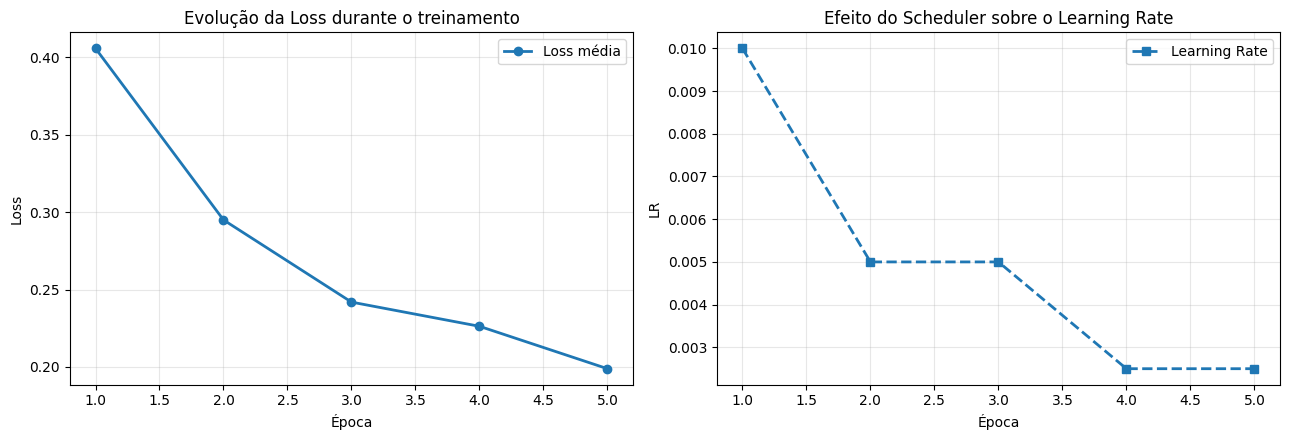

In [12]:
# ============================================================
# 4. Treinamento: Loss + Optimizer + Scheduler
# ============================================================
#
# Em cada mini-batch:
#   1. zero_grad()
#   2. forward
#   3. calcula Loss
#   4. backward
#   5. optimizer.step()
#
# Ao final da época:
#   6. scheduler.step()
#
# Isso conecta todos os conceitos explorados acima em um único fluxo.

epochs = 5
historico_loss = []
historico_acc = []
historico_lr = []

print('Iniciando o treinamento...\n')

for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    corretas = 0
    total = 0

    for images, labeQls in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        # Loss: mede o erro
        loss = criterion(outputs, labels)

        # Backpropagation: calcula gradientes
        loss.backward()

        # Optimizer: atualiza pesos
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        corretas += (predictions == labels).sum().item()
        total += labels.size(0)

    # Scheduler: modifica o learning rate
    scheduler.step()

    media_loss = running_loss / total
    acc = 100 * corretas / total
    current_lr = scheduler.get_last_lr()[0]

    historico_loss.append(media_loss)
    historico_acc.append(acc)
    historico_lr.append(current_lr)

    print(
        f'Época {epoch+1}/{epochs} | '
        f'Loss: {media_loss:.4f} | '
        f'Acurácia treino: {acc:.2f}% | '
        f'LR: {current_lr:.6f}'
    )

print('\nTreinamento finalizado!')

# Visualização do efeito conjunto da Loss e do Scheduler
ep = np.arange(1, epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(ep, historico_loss, 'o-', linewidth=2, label='Loss média')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].set_title('Evolução da Loss durante o treinamento')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(ep, historico_lr, 's--', linewidth=2, label='Learning Rate')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('LR')
axes[1].set_title('Efeito do Scheduler sobre o Learning Rate')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


---
# 5. Inferência e Classificação das Roupas

Agora que o modelo foi treinado, ele será colocado em modo de avaliação
e usado sobre **dados que não participaram do treinamento**.

Para cada imagem, a rede produz 10 *logits*. A classe prevista é aquela
com maior valor de saída.

Além de mostrar exemplos individuais, calcularemos ao final:

- número de acertos;
- número de erros;
- **porcentagem de acerto**;
- **porcentagem de erro**;
- acurácia por classe.


RESULTADO FINAL — FASHIONMNIST
Total de imagens avaliadas : 10,000
Classificações corretas    : 9,032
Classificações incorretas  : 968
Porcentagem de ACERTO      : 90.32%
Porcentagem de ERRO        : 9.68%

Acurácia por classe:
0: T-shirt/top  ->  87.70%
1: Trouser      ->  98.20%
2: Pullover     ->  82.90%
3: Dress        ->  89.00%
4: Coat         ->  88.10%
5: Sandal       ->  98.10%
6: Shirt        ->  69.80%
7: Sneaker      ->  95.80%
8: Bag          ->  97.00%
9: Ankle boot   ->  96.60%


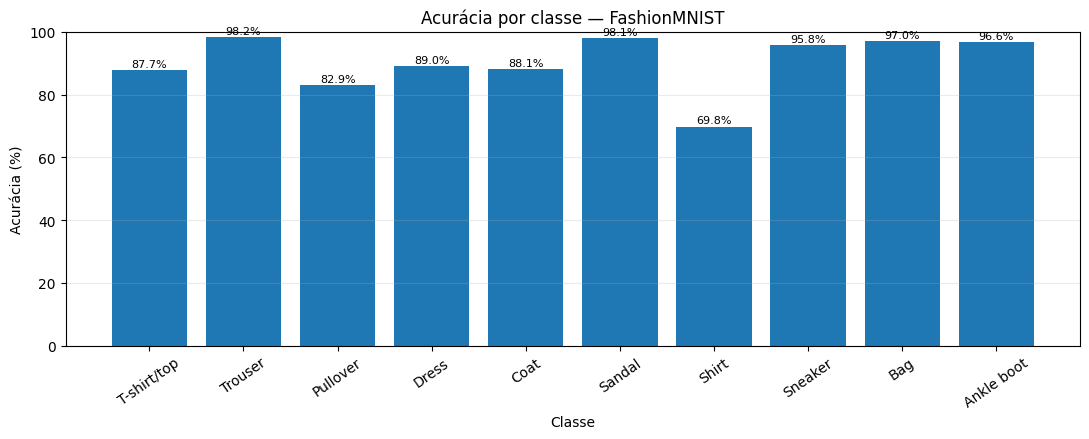

In [13]:
# ============================================================
# Inferência no conjunto de teste
# ============================================================

model.eval()

total = 0
corretas = 0
predicoes_todas = []
rotulos_todos = []

# Estatísticas por classe
corretas_classe = np.zeros(10, dtype=int)
total_classe = np.zeros(10, dtype=int)

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        total += labels.size(0)
        corretas += (predictions == labels).sum().item()

        predicoes_todas.extend(predictions.cpu().numpy())
        rotulos_todos.extend(labels.cpu().numpy())

        for classe in range(10):
            mask = labels == classe
            total_classe[classe] += mask.sum().item()
            corretas_classe[classe] += ((predictions == labels) & mask).sum().item()

acerto = 100 * corretas / total
erro = 100 - acerto

print('=' * 60)
print('RESULTADO FINAL — FASHIONMNIST')
print('=' * 60)
print(f'Total de imagens avaliadas : {total:,}')
print(f'Classificações corretas    : {corretas:,}')
print(f'Classificações incorretas  : {total - corretas:,}')
print(f'Porcentagem de ACERTO      : {acerto:.2f}%')
print(f'Porcentagem de ERRO        : {erro:.2f}%')
print('=' * 60)

# Acurácia por classe
print('\nAcurácia por classe:')
for classe, nome in enumerate(classes_fm):
    acc_classe = 100 * corretas_classe[classe] / total_classe[classe]
    print(f'{classe}: {nome:12s} -> {acc_classe:6.2f}%')

# Gráfico por classe
acc_classes = 100 * corretas_classe / total_classe

plt.figure(figsize=(11, 4.5))
bars = plt.bar(classes_fm, acc_classes)
plt.ylabel('Acurácia (%)')
plt.xlabel('Classe')
plt.title('Acurácia por classe — FashionMNIST')
plt.ylim(0, 100)
plt.xticks(rotation=35)
plt.grid(axis='y', alpha=0.25)

for bar, value in zip(bars, acc_classes):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f'{value:.1f}%',
        ha='center',
        fontsize=8
    )

plt.tight_layout()
plt.show()


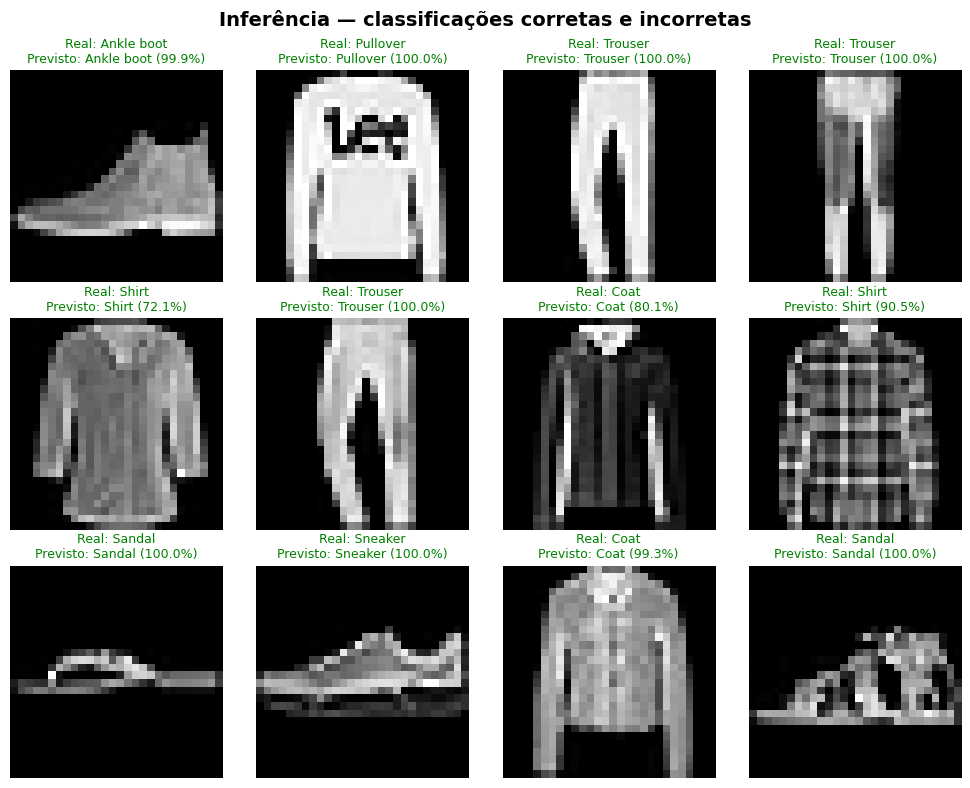

In [14]:
# ============================================================
# Visualizando classificações individuais
# ============================================================

# Selecionamos 12 imagens do conjunto de teste
images_test, labels_test = next(iter(test_loader))

with torch.no_grad():
    outputs_test = model(images_test.to(device))
    probs_test = torch.softmax(outputs_test, dim=1)
    preds_test = outputs_test.argmax(dim=1).cpu()

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
axes = axes.ravel()

for i, ax in enumerate(axes):
    real = labels_test[i].item()
    pred = preds_test[i].item()
    conf = probs_test[i, pred].item() * 100

    ax.imshow(images_test[i].squeeze().numpy(), cmap='gray')
    ax.set_title(
        f'Real: {classes_fm[real]}\n'
        f'Previsto: {classes_fm[pred]} ({conf:.1f}%)',
        color='green' if real == pred else 'red',
        fontsize=9
    )
    ax.axis('off')

fig.suptitle(
    'Inferência — classificações corretas e incorretas',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.show()


---
# 6. Salvamento e Reutilização do Modelo

Depois do treinamento, salvamos apenas os **pesos aprendidos** (`state_dict`).
Assim podemos reconstruir a arquitetura posteriormente e carregar os pesos
para realizar novas inferências sem treinar novamente.


In [15]:
# ============================================================
# Salvamento dos pesos
# ============================================================

model_path = 'fashion_mnist_cnn.pth'

torch.save(model.state_dict(), model_path)
print(f'Modelo salvo em: {model_path}')

# Demonstração: reconstruindo a arquitetura e carregando os pesos
modelo_carregado = SimpleCNN().to(device)
modelo_carregado.load_state_dict(torch.load(model_path, map_location=device))
modelo_carregado.eval()

print('Pesos carregados com sucesso.')

# Inferência de uma imagem usando o modelo recarregado
with torch.no_grad():
    imagem = images_test[0:1].to(device)
    saida = modelo_carregado(imagem)
    prob = torch.softmax(saida, dim=1)
    pred = saida.argmax(dim=1).item()

print(f'Classe real     : {classes_fm[labels_test[0].item()]}')
print(f'Classe prevista : {classes_fm[pred]}')
print(f'Confiança       : {prob[0, pred].item()*100:.2f}%')


Modelo salvo em: fashion_mnist_cnn.pth
Pesos carregados com sucesso.
Classe real     : Ankle boot
Classe prevista : Ankle boot
Confiança       : 99.92%


---
# Resumo: Encadeamento dos Conceitos

O notebook percorre todo o ciclo:

**Dados → Pré-processamento → CNN → Loss → Gradiente → Optimizer → Scheduler → Treinamento → Inferência → Avaliação → Salvamento**

A ideia central é separar os papéis:

- **Loss:** mede *quanto* o modelo errou.
- **Gradiente:** indica como a loss varia em relação aos pesos.
- **Optimizer:** decide como atualizar os pesos usando os gradientes.
- **Learning Rate:** controla o tamanho do passo.
- **Scheduler:** modifica o learning rate ao longo do treinamento.
- **Inferência:** usa os pesos aprendidos para classificar dados novos.

Explorações conceituais de **Loss, Optimizer e Scheduler** não são apenas introduções teóricas: elas são conectadas diretamente ao treinamento e ao resultado final da classificação.
